In [1]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

In [2]:
iris = load_iris()
X = iris.data

In [6]:
wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=11, n_init=10)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)

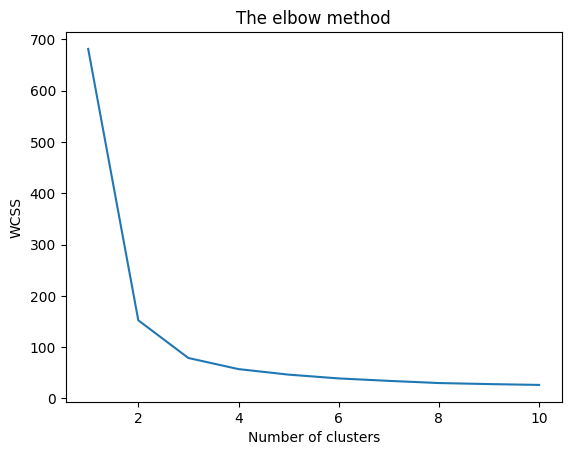

In [7]:
plt.plot(range(1, 11), wcss)
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.title('The elbow method')
plt.show()

In [8]:
kmeans = KMeans(n_clusters=3, random_state=11, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_

In [9]:
print(labels)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [10]:
import time
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

In [11]:
mnist = fetch_openml('mnist_784')
X = mnist.data
y = mnist.target

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=11)

In [13]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [15]:
start = time.time()
logisticRegr = LogisticRegression(solver = 'lbfgs', max_iter=200)
logisticRegr.fit(X_train, y_train)
y_predict = logisticRegr.predict(X_test)

time_wout_pca = time.time() - start
accuracy_wout_pca = accuracy_score(y_test, y_predict)

print("Time without PCA:", time_wout_pca)
print("Accuracy without PCA:", accuracy_wout_pca)

Time without PCA: 97.65689182281494
Accuracy without PCA: 0.9135


In [17]:
pca = PCA(0.95)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print("Original features:", X_train.shape[1])
print("PCA features:", X_train_pca.shape[1])

Original features: 328
PCA features: 237


In [21]:
start = time.time()
logisticRegr = LogisticRegression(solver = 'lbfgs', max_iter=200)
logisticRegr.fit(X_train_pca, y_train)
y_predict = logisticRegr.predict(X_test_pca)

time_w_pca = time.time() - start
accuracy_w_pca = accuracy_score(y_test, y_predict)

print("Time with PCA:", time_w_pca)
print("Accuracy with PCA:", accuracy_w_pca)

Time with PCA: 59.96970748901367
Accuracy with PCA: 0.9214285714285714


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [23]:
print("Final Results")
print("Time without PCA:", time_wout_pca)
print("Accuracy without PCA:", accuracy_wout_pca)

print("\nTime with PCA:", time_w_pca)
print("Accuracy with PCA:", accuracy_w_pca)

Final Results
Time without PCA: 97.65689182281494
Accuracy without PCA: 0.9135

Time with PCA: 59.96970748901367
Accuracy with PCA: 0.9214285714285714
